<a href="https://colab.research.google.com/github/mayanksingh232005-alt/MPLAD-AI-Risk-Analyzer/blob/main/colabnotebookcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl

**Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

print("All libraries imported successfully!")

All libraries imported successfully!


**Upload and Load Datase**

In [ ]:
!pip install python-calamine

from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_excel(
    "Allocated Limit for Honble MPs.xlsx",
    engine="calamine"
)

print(df.shape)
df.head()

Saving Allocated Limit for Honble MPs.xlsx to Allocated Limit for Honble MPs (10).xlsx
(233, 5)


,Allocated Limit for Hon'ble MPs,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ )
1,1,Telangana,Dr. Abhishek Manu Singhvi (2026-32) (2026-2032),Elected MP,49000000
2,2,Maharashtra,Dr. Ajeet Madhavrao Gopchade (2024-30) (2024-2...,Elected MP,147000000
3,3,Rajasthan,Dr. Alka Singh (2026-32) (2026-2032),Elected MP,49000000
4,4,Tamil Nadu,Dr. Anbumani Ramadoss (2026-32) (2026-2032),Elected MP,49000000


**Correct Dataset Header and Reload Data**

In [ ]:
# Correct header row को dataframe का header बनाना
df = pd.read_excel(
    list(uploaded.keys())[0],
    engine="calamine",
    header=1
)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Shape: (232, 5)
Columns:
['Sr. No.', 'State', "Hon'ble Members of Parliament", 'Elected/Nominated', 'Allocated AMOUNT ( ₹ )']


,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ )
0,1,Telangana,Dr. Abhishek Manu Singhvi (2026-32) (2026-2032),Elected MP,4.900000e+07
1,2,Maharashtra,Dr. Ajeet Madhavrao Gopchade (2024-30) (2024-2...,Elected MP,1.470000e+08
2,3,Rajasthan,Dr. Alka Singh (2026-32) (2026-2032),Elected MP,4.900000e+07
3,4,Tamil Nadu,Dr. Anbumani Ramadoss (2026-32) (2026-2032),Elected MP,4.900000e+07
4,5,Maharashtra,Dr. Anil Sukhdeorao Bonde (2022-28) (2022-2028),Elected MP,1.960640e+08


**Data Quality Assessment**

In [ ]:
print("DATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nDUPLICATE ROWS:")
print(df.duplicated().sum())

DATA TYPES:
Sr. No.                           object
State                             object
Hon'ble Members of Parliament     object
Elected/Nominated                 object
Allocated AMOUNT ( ₹ )           float64
dtype: object

MISSING VALUES:
Sr. No.                          0
State                            1
Hon'ble Members of Parliament    1
Elected/Nominated                1
Allocated AMOUNT ( ₹ )           0
dtype: int64

DUPLICATE ROWS:
0


**Identification of Missing Records**

In [ ]:
missing_rows = df[df.isnull().any(axis=1)]

print("Rows containing missing values:")
display(missing_rows)

Rows containing missing values:


,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ )
231,Grand Total,NaN,NaN,NaN,3.361335e+10


**Remove Summary Records and Recheck Data Quality**

In [ ]:
# Remove the Excel summary row "Grand Total"
df = df[df["Sr. No."].astype(str).str.strip().str.lower() != "grand total"].copy()

print("Shape after removing Grand Total:", df.shape)
print("\nMissing values after removing Grand Total:")
print(df.isnull().sum())

Shape after removing Grand Total: (231, 5)

Missing values after removing Grand Total:
Sr. No.                          0
State                            0
Hon'ble Members of Parliament    0
Elected/Nominated                0
Allocated AMOUNT ( ₹ )           0
dtype: int64


**Identify and Analyze Allocated Amount**

In [ ]:
# Find the Allocated Amount column automatically
amount_col = [col for col in df.columns if "Allocated" in str(col) and "AMOUNT" in str(col)][0]

print("Amount column found:")
print(repr(amount_col))

print("\nData type:")
print(df[amount_col].dtype)

print("\nFirst 10 amount values:")
print(df[amount_col].head(10).tolist())

print("\nAmount summary:")
print(df[amount_col].describe())

Amount column found:
'Allocated AMOUNT ( ₹ )'

Data type:
float64

First 10 amount values:
[49000000.0, 147000000.0, 49000000.0, 49000000.0, 196063957.11, 222487632.14, 186200000.0, 196063957.11, 186200000.0, 147000000.0]

Amount summary:
count    2.310000e+02
mean     1.455123e+08
std      6.861924e+07
min      2.380001e+07
25%      7.350000e+07
50%      1.470000e+08
75%      1.960640e+08
max      3.108990e+08
Name: Allocated AMOUNT ( ₹ ), dtype: float64


**Categorical Data Quality Analysis**

In [ ]:
# Check unique values and possible extra spaces in categorical columns

text_cols = [
    "State",
    "Hon'ble Members of Parliament",
    "Elected/Nominated"
]

for col in text_cols:
    print("\n" + "=" * 60)
    print("COLUMN:", col)
    print("Unique values:", df[col].nunique())
    print("Missing values:", df[col].isnull().sum())
    print("Sample values:")
    print(df[col].dropna().head(10).tolist())


COLUMN: State
Unique values: 32
Missing values: 0
Sample values:
['Telangana', 'Maharashtra', 'Rajasthan', 'Tamil Nadu', 'Maharashtra', 'Punjab', 'Bihar', 'Karnataka', 'Bihar', 'Uttar Pradesh']

COLUMN: Hon'ble Members of Parliament
Unique values: 231
Missing values: 0
Sample values:
['Dr. Abhishek Manu Singhvi (2026-32) (2026-2032)', 'Dr. Ajeet Madhavrao Gopchade (2024-30) (2024-2030)', 'Dr. Alka Singh (2026-32) (2026-2032)', 'Dr. Anbumani Ramadoss (2026-32) (2026-2032)', 'Dr. Anil Sukhdeorao Bonde (2022-28) (2022-2028)', 'Dr. Ashok Kumar Mittal (2022-28) (2022-2028)', 'Dr. Bhim Singh (2024-30) (2024-2030)', 'Dr. Dharmasthala Veerendra Heggade (2022-28) (2022-2028)', 'Dr. Dharmshila Gupta (2024-30) (2024-2030)', 'Dr. Dinesh Sharma (2023-26) (2023-2026)']

COLUMN: Elected/Nominated
Unique values: 2
Missing values: 0
Sample values:
['Elected MP', 'Elected MP', 'Elected MP', 'Elected MP', 'Elected MP', 'Elected MP', 'Elected MP', 'Nominated MP', 'Elected MP', 'Elected MP']


**Detect Inconsistent Whitespace in Categorical Data**

In [ ]:
for col in ["State", "Hon'ble Members of Parliament", "Elected/Nominated"]:
    print("\n" + "=" * 60)
    print("COLUMN:", col)

    values = df[col].astype(str)

    leading_spaces = (values != values.str.lstrip()).sum()
    trailing_spaces = (values != values.str.rstrip()).sum()

    print("Leading spaces:", leading_spaces)
    print("Trailing spaces:", trailing_spaces)


COLUMN: State
Leading spaces: 0
Trailing spaces: 0

COLUMN: Hon'ble Members of Parliament
Leading spaces: 0
Trailing spaces: 0

COLUMN: Elected/Nominated
Leading spaces: 0
Trailing spaces: 0


**Feature Engineering: Extract Parliamentary Term Years**

In [ ]:
import re

mp_col = "Hon'ble Members of Parliament"

# Extract starting and ending years
df["Term_Start_Year"] = df[mp_col].str.extract(r"\((\d{4})-\d{2}\)")[0]
df["Term_End_Year"] = df[mp_col].str.extract(r"\((\d{4})-(\d{4})\)")[0]

# Convert extracted values to numeric
df["Term_Start_Year"] = pd.to_numeric(df["Term_Start_Year"], errors="coerce")
df["Term_End_Year"] = pd.to_numeric(df["Term_End_Year"], errors="coerce")

print("New features created:")
print(["Term_Start_Year", "Term_End_Year"])

display(df[[mp_col, "Term_Start_Year", "Term_End_Year"]].head(10))

New features created:
['Term_Start_Year', 'Term_End_Year']


,Hon'ble Members of Parliament,Term_Start_Year,Term_End_Year
0,Dr. Abhishek Manu Singhvi (2026-32) (2026-2032),2026,2026
1,Dr. Ajeet Madhavrao Gopchade (2024-30) (2024-2...,2024,2024
2,Dr. Alka Singh (2026-32) (2026-2032),2026,2026
3,Dr. Anbumani Ramadoss (2026-32) (2026-2032),2026,2026
4,Dr. Anil Sukhdeorao Bonde (2022-28) (2022-2028),2022,2022
5,Dr. Ashok Kumar Mittal (2022-28) (2022-2028),2022,2022
6,Dr. Bhim Singh (2024-30) (2024-2030),2024,2024
7,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,2022,2022
8,Dr. Dharmshila Gupta (2024-30) (2024-2030),2024,2024
9,Dr. Dinesh Sharma (2023-26) (2023-2026),2023,2023


**Prepare and Transform Model Feature**

In [ ]:
# ================================
# CELL 12: Prepare Model Features
# ================================

# Categorical columns
categorical_cols = [
    "State",
    "Elected/Nominated"
]

# Numerical columns
numerical_cols = [
    amount_col,
    "Term_Start_Year",
    "Term_End_Year"
]

# One-hot encode categorical features
df_model = pd.get_dummies(
    df[categorical_cols + numerical_cols],
    columns=categorical_cols,
    drop_first=False
)

# Make sure all model features are numeric
df_model = df_model.astype(float)

print("Model-ready dataset shape:", df_model.shape)

print("\nModel features:")
print(df_model.columns.tolist())

print("\nFirst 5 rows:")
display(df_model.head())

Model-ready dataset shape: (231, 37)

Model features:
['Allocated AMOUNT ( ₹ )', 'Term_Start_Year', 'Term_End_Year', 'State_Andhra Pradesh', 'State_Arunachal Pradesh', 'State_Assam', 'State_Bihar', 'State_Chandigarh', 'State_Chhattisgarh', 'State_Delhi', 'State_Goa', 'State_Gujarat', 'State_Haryana', 'State_Himachal Pradesh', 'State_Jammu And Kashmir', 'State_Jharkhand', 'State_Karnataka', 'State_Kerala', 'State_Madhya Pradesh', 'State_Maharashtra', 'State_Manipur', 'State_Meghalaya', 'State_Mizoram', 'State_Nagaland', 'State_Odisha', 'State_Puducherry', 'State_Punjab', 'State_Rajasthan', 'State_Sikkim', 'State_Tamil Nadu', 'State_Telangana', 'State_Tripura', 'State_Uttar Pradesh', 'State_Uttarakhand', 'State_West Bengal', 'Elected/Nominated_Elected MP', 'Elected/Nominated_Nominated MP']

First 5 rows:


,Allocated AMOUNT ( ₹ ),Term_Start_Year,Term_End_Year,State_Andhra Pradesh,State_Arunachal Pradesh,State_Assam,State_Bihar,State_Chandigarh,State_Chhattisgarh,State_Delhi,...,State_Rajasthan,State_Sikkim,State_Tamil Nadu,State_Telangana,State_Tripura,State_Uttar Pradesh,State_Uttarakhand,State_West Bengal,Elected/Nominated_Elected MP,Elected/Nominated_Nominated MP
0,4.900000e+07,2026.0,2026.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.470000e+08,2024.0,2024.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4.900000e+07,2026.0,2026.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4.900000e+07,2026.0,2026.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.960640e+08,2022.0,2022.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Feature Scaling**

In [ ]:
# ================================
# CELL 13: Feature Scaling
# ================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_model)

print("Original feature shape:", df_model.shape)
print("Scaled feature shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Original feature shape: (231, 37)
Scaled feature shape: (231, 37)

First 5 scaled rows:
[[-1.40954496  1.32899569  1.32899569 -0.23408229 -0.06593805 -0.1767767
  -0.26352314 -0.06593805 -0.14874103 -0.13274466 -0.06593805 -0.20134682
  -0.14874103 -0.11470787 -0.14874103 -0.14874103 -0.25400025 -0.2236068
  -0.2236068  -0.29070095 -0.06593805 -0.06593805 -0.06593805 -0.06593805
  -0.21271781 -0.06593805 -0.1767767  -0.21271781 -0.06593805 -0.29937041
   6.12372436 -0.06593805 -0.39370039 -0.11470787 -0.2236068   0.2236068
  -0.2236068 ]
 [ 0.02172717  0.16391787  0.16391787 -0.23408229 -0.06593805 -0.1767767
  -0.26352314 -0.06593805 -0.14874103 -0.13274466 -0.06593805 -0.20134682
  -0.14874103 -0.11470787 -0.14874103 -0.14874103 -0.25400025 -0.2236068
  -0.2236068   3.43996124 -0.06593805 -0.06593805 -0.06593805 -0.06593805
  -0.21271781 -0.06593805 -0.1767767  -0.21271781 -0.06593805 -0.29937041
  -0.16329932 -0.06593805 -0.39370039 -0.11470787 -0.2236068   0.2236068
  -0.2236068 ]


**Build and Train Anomaly Detection Model**

In [ ]:
# ==========================================
# CELL 14: Build the Anomaly Detection Model
# ==========================================

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42
)

# Train the model
model.fit(X_scaled)

# Generate predictions
df["Anomaly_Prediction"] = model.predict(X_scaled)

# Convert prediction into easy-to-understand labels
df["Anomaly_Label"] = df["Anomaly_Prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

print("Model trained successfully!")

print("\nPrediction counts:")
print(df["Anomaly_Label"].value_counts())

Model trained successfully!

Prediction counts:
Anomaly_Label
Normal     208
Anomaly     23
Name: count, dtype: int64


**View and Analyze Detected Anomalies**

In [ ]:
# ==========================================
# CELL 15: View Detected Anomalies
# ==========================================

anomalies = df[df["Anomaly_Label"] == "Anomaly"].copy()

print("Total anomalies detected:", len(anomalies))

display(
    anomalies[
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            "Elected/Nominated",
            amount_col,
            "Term_Start_Year",
            "Term_End_Year",
            "Anomaly_Label"
        ]
    ].sort_values(by=amount_col, ascending=False)
)

Total anomalies detected: 23


,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ ),Term_Start_Year,Term_End_Year,Anomaly_Label
41,42,Kerala,Shri Abdul Wahab (2021-27) (2021-2027),Elected MP,3.108990e+08,2021,2021,Anomaly
169,170,Puducherry,Shri S. Selvaganabathy (2021-27) (2021-2027),Elected MP,2.928819e+08,2021,2021,Anomaly
34,35,Kerala,Dr. V. Sivadasan (2021-27) (2021-2027),Elected MP,2.767203e+08,2021,2021,Anomaly
11,12,Kerala,Dr. John Brittas (2021-27) (2021-2027),Elected MP,2.450640e+08,2021,2021,Anomaly
131,132,Uttar Pradesh,Shri Neeraj Shekhar (2020-26) (2020-2026),Elected MP,2.364837e+08,2020,2020,Anomaly
128,129,Uttarakhand,Shri Naresh Bansal (2020-26) (2020-2026),Elected MP,2.220432e+08,2020,2020,Anomaly
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),Nominated MP,2.205640e+08,2022,2022,Anomaly
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,Anomaly
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,Anomaly
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,Nominated MP,1.960640e+08,2022,2022,Anomaly


**Generate and Rank Anomaly Scores**

In [ ]:
# ==========================================
# CELL 16: Generate Anomaly Scores
# ==========================================

df["Anomaly_Score"] = model.decision_function(X_scaled)

# More negative score = more unusual
anomalies = (
    df[df["Anomaly_Label"] == "Anomaly"]
    .sort_values("Anomaly_Score")
)

print("Most unusual records:")
display(
    anomalies[
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            amount_col,
            "Anomaly_Score",
            "Anomaly_Label"
        ]
    ].head(10)
)

Most unusual records:


,Sr. No.,State,Hon'ble Members of Parliament,Allocated AMOUNT ( ₹ ),Anomaly_Score,Anomaly_Label
62,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),7.350000e+07,-0.069138,Anomaly
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),1.960640e+08,-0.067959,Anomaly
85,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),7.350000e+07,-0.066479,Anomaly
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),2.205640e+08,-0.066326,Anomaly
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),1.960640e+08,-0.065651,Anomaly
79,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),1.960640e+08,-0.060056,Anomaly
21,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),7.350000e+07,-0.059549,Anomaly
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,1.960640e+08,-0.055537,Anomaly
186,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),1.470000e+08,-0.051429,Anomaly
198,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),7.350000e+07,-0.050685,Anomaly


**Visualize Normal vs Anomalous Records**

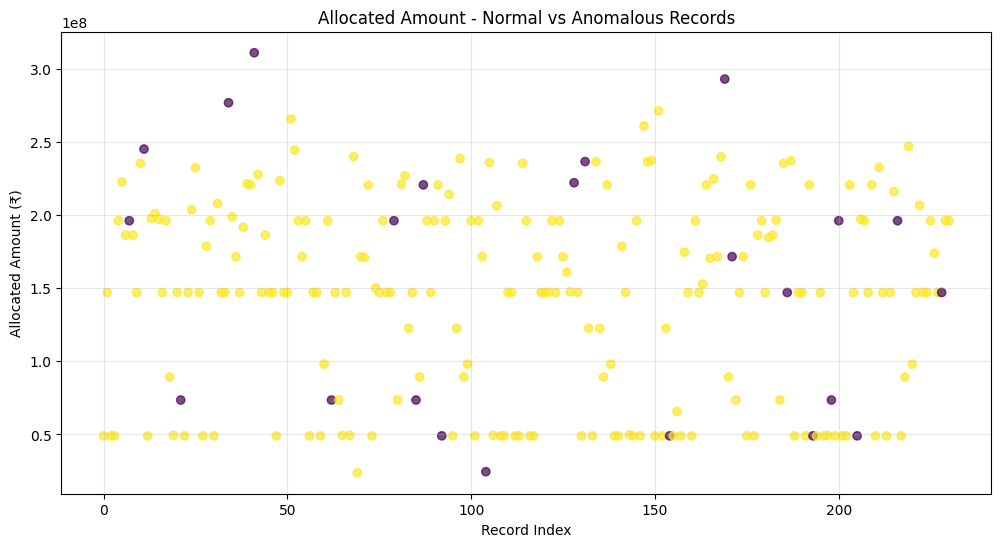

In [ ]:
# ==========================================
# CELL 17: Anomaly Visualization
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(df)),
    df[amount_col],
    c=df["Anomaly_Prediction"],
    alpha=0.7
)

plt.xlabel("Record Index")
plt.ylabel("Allocated Amount (₹)")
plt.title("Allocated Amount - Normal vs Anomalous Records")
plt.grid(True, alpha=0.3)

plt.show()

**Final Anomaly Detection Model Summary**

In [ ]:
# ==========================================
# CELL 18: Final Model Summary
# ==========================================

total_records = len(df)
normal_records = (df["Anomaly_Label"] == "Normal").sum()
anomaly_records = (df["Anomaly_Label"] == "Anomaly").sum()

anomaly_percentage = (anomaly_records / total_records) * 100

print("========== MODEL SUMMARY ==========")
print("Total Records      :", total_records)
print("Normal Records     :", normal_records)
print("Anomalous Records  :", anomaly_records)
print("Anomaly Percentage : {:.2f}%".format(anomaly_percentage))
print("===================================")

========== MODEL SUMMARY ==========
Total Records      : 231
Normal Records     : 208
Anomalous Records  : 23
Anomaly Percentage : 9.96%


**Generate Final Anomaly Report**

In [ ]:
# ==========================================
# CELL 19: Final Anomaly Report
# ==========================================

final_anomaly_report = (
    df[df["Anomaly_Label"] == "Anomaly"]
    [
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            "Elected/Nominated",
            amount_col,
            "Term_Start_Year",
            "Term_End_Year",
            "Anomaly_Score",
            "Anomaly_Label"
        ]
    ]
    .sort_values(by="Anomaly_Score", ascending=True)
    .reset_index(drop=True)
)

print("FINAL ANOMALY REPORT")
print("Number of anomalous records:", len(final_anomaly_report))

display(final_anomaly_report)

FINAL ANOMALY REPORT
Number of anomalous records: 23


,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ ),Term_Start_Year,Term_End_Year,Anomaly_Score,Anomaly_Label
0,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.069138,Anomaly
1,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.067959,Anomaly
2,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.066479,Anomaly
3,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),Nominated MP,2.205640e+08,2022,2022,-0.066326,Anomaly
4,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.065651,Anomaly
5,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.060056,Anomaly
6,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.059549,Anomaly
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,Nominated MP,1.960640e+08,2022,2022,-0.055537,Anomaly
8,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),Nominated MP,1.470000e+08,2024,2024,-0.051429,Anomaly
9,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.050685,Anomaly


**Calculate Risk Score and Classify Risk Level**

In [ ]:
# ==========================================
# CELL 20: Risk Score and Risk Level
# ==========================================

# Convert anomaly score into a 0-100 risk score
min_score = df["Anomaly_Score"].min()
max_score = df["Anomaly_Score"].max()

df["Risk_Score"] = (
    (max_score - df["Anomaly_Score"])
    / (max_score - min_score)
) * 100

# Risk categories
def get_risk_level(score):
    if score >= 70:
        return "High Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df["Risk_Score"].apply(get_risk_level)

# Show highest-risk projects
top_risk = (
    df.sort_values("Risk_Score", ascending=False)
      .head(10)
)

display(
    top_risk[
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            amount_col,
            "Risk_Score",
            "Risk_Level"
        ]
    ]
)

,Sr. No.,State,Hon'ble Members of Parliament,Allocated AMOUNT ( ₹ ),Risk_Score,Risk_Level
62,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),7.350000e+07,100.000000,High Risk
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),1.960640e+08,98.956732,High Risk
85,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),7.350000e+07,97.646963,High Risk
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),2.205640e+08,97.511837,High Risk
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),1.960640e+08,96.914589,High Risk
79,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),1.960640e+08,91.964685,High Risk
21,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),7.350000e+07,91.516236,High Risk
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,1.960640e+08,87.966222,High Risk
186,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),1.470000e+08,84.331896,High Risk
198,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),7.350000e+07,83.673876,High Risk


**Explain Anomaly Reasons and Risk Factors**

In [ ]:
# ==========================================
# CELL 21: Explain Why a Record Was Flagged
# ==========================================

# Calculate basic dataset statistics
amount_mean = df[amount_col].mean()
amount_std = df[amount_col].std()

def generate_reason(row):

    reasons = []

    # Check unusually high allocation
    if row[amount_col] > amount_mean + 2 * amount_std:
        reasons.append("Allocated amount is unusually high")

    # Check unusually low allocation
    elif row[amount_col] < amount_mean - 2 * amount_std:
        reasons.append("Allocated amount is unusually low")

    # Check ML anomaly
    if row["Anomaly_Label"] == "Anomaly":
        reasons.append("Unusual pattern detected by ML model")

    # Fallback
    if not reasons:
        reasons.append("Pattern differs from the normal data distribution")

    return reasons


df["Risk_Reasons"] = df.apply(generate_reason, axis=1)

# Show top 10 high-risk records
top_risk = df.sort_values(
    "Risk_Score",
    ascending=False
).head(10)

display(
    top_risk[
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            amount_col,
            "Risk_Score",
            "Risk_Level",
            "Risk_Reasons"
        ]
    ]
)

,Sr. No.,State,Hon'ble Members of Parliament,Allocated AMOUNT ( ₹ ),Risk_Score,Risk_Level,Risk_Reasons
62,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),7.350000e+07,100.000000,High Risk,[Unusual pattern detected by ML model]
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),1.960640e+08,98.956732,High Risk,[Unusual pattern detected by ML model]
85,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),7.350000e+07,97.646963,High Risk,[Unusual pattern detected by ML model]
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),2.205640e+08,97.511837,High Risk,[Unusual pattern detected by ML model]
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),1.960640e+08,96.914589,High Risk,[Unusual pattern detected by ML model]
79,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),1.960640e+08,91.964685,High Risk,[Unusual pattern detected by ML model]
21,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),7.350000e+07,91.516236,High Risk,[Unusual pattern detected by ML model]
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,1.960640e+08,87.966222,High Risk,[Unusual pattern detected by ML model]
186,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),1.470000e+08,84.331896,High Risk,[Unusual pattern detected by ML model]
198,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),7.350000e+07,83.673876,High Risk,[Unusual pattern detected by ML model]


**Build Demo Dashboard for Anomaly and Risk Analysis**

        MP ALLOCATION ANOMALY DETECTION DASHBOARD

Total Records       : 231
Normal Records      : 208
Anomalous Records   : 23
Anomaly Percentage  : 9.96%

RISK DISTRIBUTION
------------------------------
High Risk           : 12
Medium Risk         : 10
Low Risk            : 209

TOP 10 HIGH-RISK RECORDS
------------------------------------------------------------


,Sr. No.,State,Hon'ble Members of Parliament,Allocated AMOUNT ( ₹ ),Risk_Score,Risk_Level
62,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),7.350000e+07,100.000000,High Risk
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),1.960640e+08,98.956732,High Risk
85,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),7.350000e+07,97.646963,High Risk
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),2.205640e+08,97.511837,High Risk
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),1.960640e+08,96.914589,High Risk
79,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),1.960640e+08,91.964685,High Risk
21,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),7.350000e+07,91.516236,High Risk
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,1.960640e+08,87.966222,High Risk
186,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),1.470000e+08,84.331896,High Risk
198,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),7.350000e+07,83.673876,High Risk


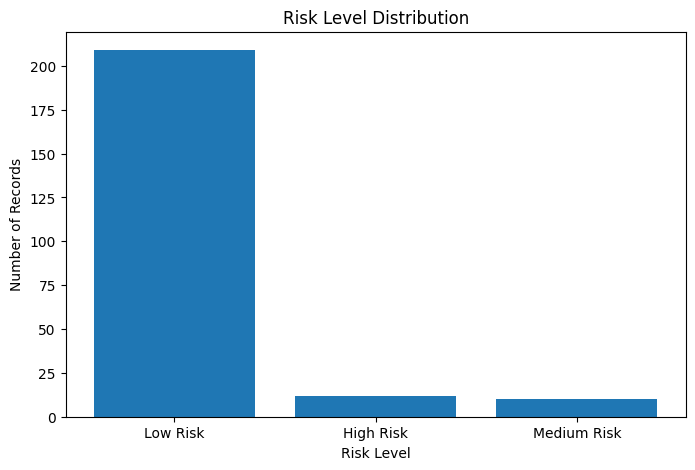

In [ ]:
# ==========================================
# CELL 22: DEMO DASHBOARD
# ==========================================

import matplotlib.pyplot as plt

# Summary numbers
total_records = len(df)
normal_count = (df["Anomaly_Label"] == "Normal").sum()
anomaly_count = (df["Anomaly_Label"] == "Anomaly").sum()

high_risk_count = (df["Risk_Level"] == "High Risk").sum()
medium_risk_count = (df["Risk_Level"] == "Medium Risk").sum()
low_risk_count = (df["Risk_Level"] == "Low Risk").sum()

print("=" * 60)
print("        MP ALLOCATION ANOMALY DETECTION DASHBOARD")
print("=" * 60)

print(f"\nTotal Records       : {total_records}")
print(f"Normal Records      : {normal_count}")
print(f"Anomalous Records   : {anomaly_count}")
print(f"Anomaly Percentage  : {(anomaly_count / total_records) * 100:.2f}%")

print("\nRISK DISTRIBUTION")
print("-" * 30)
print(f"High Risk           : {high_risk_count}")
print(f"Medium Risk         : {medium_risk_count}")
print(f"Low Risk            : {low_risk_count}")

print("\nTOP 10 HIGH-RISK RECORDS")
print("-" * 60)

display(
    df.sort_values("Risk_Score", ascending=False)
      [
          [
              "Sr. No.",
              "State",
              "Hon'ble Members of Parliament",
              amount_col,
              "Risk_Score",
              "Risk_Level"
          ]
      ]
      .head(10)
)

# Risk distribution chart
risk_counts = df["Risk_Level"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

**Clean Dataset and Retrain the Anomaly Detection Mode**

In [ ]:
# ==========================================
# CELL 23: Remove Grand Total & Retrain Model
# ==========================================

# Remove aggregate/summary row
df = df[
    df["State"].notna() &
    (df["State"].astype(str).str.strip().str.lower() != "grand total")
].copy()

df.reset_index(drop=True, inplace=True)

print("Clean dataset shape:", df.shape)

# -------------------------------
# Rebuild model features
# -------------------------------

categorical_cols = [
    "State",
    "Elected/Nominated"
]

numerical_cols = [
    amount_col,
    "Term_Start_Year",
    "Term_End_Year"
]

df_model = pd.get_dummies(
    df[categorical_cols + numerical_cols],
    columns=categorical_cols,
    drop_first=False
)

df_model = df_model.astype(float)

# -------------------------------
# Scale features
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

# -------------------------------
# Retrain Isolation Forest
# -------------------------------

model = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42
)

model.fit(X_scaled)

# -------------------------------
# Predictions
# -------------------------------

df["Anomaly_Prediction"] = model.predict(X_scaled)

df["Anomaly_Label"] = df["Anomaly_Prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

# -------------------------------
# Anomaly Score
# -------------------------------

df["Anomaly_Score"] = model.decision_function(X_scaled)

# -------------------------------
# Risk Score
# -------------------------------

min_score = df["Anomaly_Score"].min()
max_score = df["Anomaly_Score"].max()

df["Risk_Score"] = (
    (max_score - df["Anomaly_Score"])
    / (max_score - min_score)
) * 100

# -------------------------------
# Risk Level
# -------------------------------

def get_risk_level(score):
    if score >= 70:
        return "High Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df["Risk_Score"].apply(get_risk_level)

print("\n========== UPDATED MODEL ==========")
print("Total records:", len(df))
print("\nPrediction counts:")
print(df["Anomaly_Label"].value_counts())

print("\nRisk distribution:")
print(df["Risk_Level"].value_counts())

Clean dataset shape: (231, 13)

========== UPDATED MODEL ==========
Total records: 231

Prediction counts:
Anomaly_Label
Normal     208
Anomaly     23
Name: count, dtype: int64

Risk distribution:
Risk_Level
Low Risk       209
High Risk       12
Medium Risk     10
Name: count, dtype: int64


**Generate Final High-Risk Anomaly Report**

In [ ]:
# ==========================================
# CELL 24: FINAL HIGH-RISK REPORT
# ==========================================

final_report = (
    df[df["Anomaly_Label"] == "Anomaly"]
    .sort_values("Risk_Score", ascending=False)
    [
        [
            "Sr. No.",
            "State",
            "Hon'ble Members of Parliament",
            "Elected/Nominated",
            amount_col,
            "Term_Start_Year",
            "Term_End_Year",
            "Anomaly_Score",
            "Risk_Score",
            "Risk_Level"
        ]
    ]
    .reset_index(drop=True)
)

print("FINAL ANOMALY REPORT")
print("=" * 70)
print("Total anomalous records:", len(final_report))

display(final_report)

FINAL ANOMALY REPORT
Total anomalous records: 23


,Sr. No.,State,Hon'ble Members of Parliament,Elected/Nominated,Allocated AMOUNT ( ₹ ),Term_Start_Year,Term_End_Year,Anomaly_Score,Risk_Score,Risk_Level
0,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.069138,100.000000,High Risk
1,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.067959,98.956732,High Risk
2,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.066479,97.646963,High Risk
3,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),Nominated MP,2.205640e+08,2022,2022,-0.066326,97.511837,High Risk
4,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.065651,96.914589,High Risk
5,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),Nominated MP,1.960640e+08,2022,2022,-0.060056,91.964685,High Risk
6,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.059549,91.516236,High Risk
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,Nominated MP,1.960640e+08,2022,2022,-0.055537,87.966222,High Risk
8,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),Nominated MP,1.470000e+08,2024,2024,-0.051429,84.331896,High Risk
9,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),Nominated MP,7.350000e+07,2025,2025,-0.050685,83.673876,High Risk


**Interactive MP Risk Lookup Dashboard**

In [ ]:
# ==========================================
# CELL 25: INTERACTIVE MP RISK LOOKUP
# ==========================================

from IPython.display import display, clear_output
import ipywidgets as widgets

# MP selection dropdown
mp_dropdown = widgets.Dropdown(
    options=df["Hon'ble Members of Parliament"].tolist(),
    description="Select MP:",
    layout=widgets.Layout(width="90%")
)

output = widgets.Output()

def show_mp_result(change):
    with output:
        clear_output(wait=True)

        selected_mp = change["new"]

        result = df[
            df["Hon'ble Members of Parliament"] == selected_mp
        ].iloc[0]

        print("=" * 70)
        print("              MP ALLOCATION RISK REPORT")
        print("=" * 70)

        print(f"\nMP Name       : {result['Hon\'ble Members of Parliament']}")
        print(f"State         : {result['State']}")
        print(f"Status        : {result['Elected/Nominated']}")
        print(f"Allocated Amt : ₹{result[amount_col]:,.2f}")
        print(f"Risk Score    : {result['Risk_Score']:.2f}/100")
        print(f"Risk Level    : {result['Risk_Level']}")
        print(f"ML Prediction : {result['Anomaly_Label']}")

        print("\n" + "-" * 70)
        print("INTERPRETATION")
        print("-" * 70)

        if result["Anomaly_Label"] == "Anomaly":
            print("⚠ This record has been flagged by the anomaly detection model.")
            print("It requires further human/data verification.")
        else:
            print("✓ This record follows the patterns learned from the dataset.")

        print("=" * 70)


mp_dropdown.observe(show_mp_result, names="value")

display(mp_dropdown)
display(output)

# Show first selected MP immediately
show_mp_result({"new": mp_dropdown.value})

Dropdown(description='Select MP:', layout=Layout(width='90%'), options=('Dr. Abhishek Manu Singhvi (2026-32) (…

Output()

**Build Final Professional Anomaly Detection Dashboard**


FINANCIAL SUMMARY
Total Allocated Amount : ₹33,613,347,899.82
Average Allocation     : ₹145,512,328.57

RISK DISTRIBUTION
High Risk   : 12
Medium Risk : 10
Low Risk    : 209


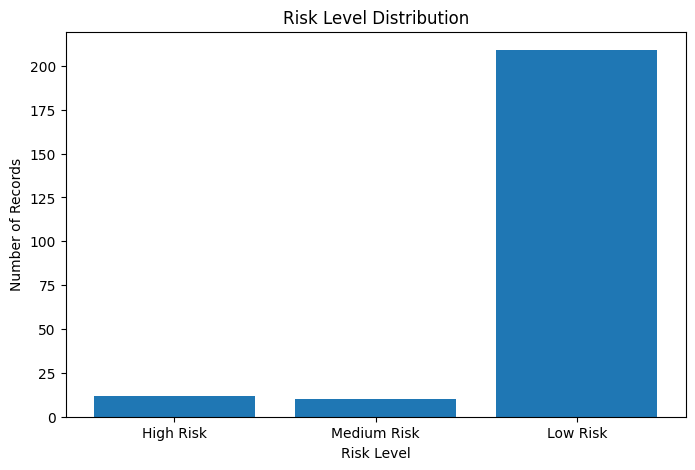


TOP 10 HIGH-RISK RECORDS


,Sr. No.,State,Hon'ble Members of Parliament,Allocated AMOUNT ( ₹ ),Risk_Score,Risk_Level
62,63,Kerala,Shri C. Sadanandan Master (2025-31) (2025-2031),7.350000e+07,100.000000,High Risk
216,217,Kerala,Smt. P. T. Usha (2022-28) (2022-2028),1.960640e+08,98.956732,High Risk
85,86,West Bengal,Shri Harsh Vardhan Shringla (2025-31) (2025-2031),7.350000e+07,97.646963,High Risk
87,88,Tamil Nadu,Shri Ilaiyaraaja (2022-28) (2022-2028),2.205640e+08,97.511837,High Risk
200,201,Andhra Pradesh,Shri V. Vijayendra Prasad (2022-28) (2022-2028),1.960640e+08,96.914589,High Risk
79,80,Jammu And Kashmir,Shri Gulam Ali (2022-28) (2022-2028),1.960640e+08,91.964685,High Risk
21,22,Delhi,Dr. Meenakshi Jain (2025-31) (2025-2031),7.350000e+07,91.516236,High Risk
7,8,Karnataka,Dr. Dharmasthala Veerendra Heggade (2022-28) (...,1.960640e+08,87.966222,High Risk
186,187,Chandigarh,Shri Satnam Singh Sandhu (2024-30) (2024-2030),1.470000e+08,84.331896,High Risk
198,199,Maharashtra,Shri Ujjwal Deorao Nikam (2025-31) (2025-2031),7.350000e+07,83.673876,High Risk


In [ ]:
# ==========================================
# CELL 26: FINAL PROFESSIONAL DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
from IPython.display import display, HTML

# -------------------------------
# Summary calculations
# -------------------------------

total_records = len(df)

normal_count = (df["Anomaly_Label"] == "Normal").sum()
anomaly_count = (df["Anomaly_Label"] == "Anomaly").sum()

high_risk_count = (df["Risk_Level"] == "High Risk").sum()
medium_risk_count = (df["Risk_Level"] == "Medium Risk").sum()
low_risk_count = (df["Risk_Level"] == "Low Risk").sum()

anomaly_percentage = (anomaly_count / total_records) * 100

total_allocated = df[amount_col].sum()
average_allocated = df[amount_col].mean()

# -------------------------------
# Dashboard Header
# -------------------------------

display(HTML("""
<h1 style="text-align:center;">
MP Allocation Anomaly Detection Dashboard
</h1>

<p style="text-align:center;">
AI-based statistical anomaly screening of MP allocation records
</p>
"""))

# -------------------------------
# KPI Cards
# -------------------------------

display(HTML(f"""
<div style="
display:flex;
gap:15px;
flex-wrap:wrap;
margin:20px 0;
">

<div style="padding:20px;border:1px solid #ccc;border-radius:10px;">
<b>Total Records</b><br>
<span style="font-size:25px;">{total_records}</span>
</div>

<div style="padding:20px;border:1px solid #ccc;border-radius:10px;">
<b>Normal</b><br>
<span style="font-size:25px;">{normal_count}</span>
</div>

<div style="padding:20px;border:1px solid #ccc;border-radius:10px;">
<b>Anomalies</b><br>
<span style="font-size:25px;">{anomaly_count}</span>
</div>

<div style="padding:20px;border:1px solid #ccc;border-radius:10px;">
<b>Anomaly %</b><br>
<span style="font-size:25px;">{anomaly_percentage:.2f}%</span>
</div>

<div style="padding:20px;border:1px solid #ccc;border-radius:10px;">
<b>High Risk</b><br>
<span style="font-size:25px;">{high_risk_count}</span>
</div>

</div>
"""))

# -------------------------------
# Financial Summary
# -------------------------------

print("\nFINANCIAL SUMMARY")
print("=" * 50)

print(f"Total Allocated Amount : ₹{total_allocated:,.2f}")
print(f"Average Allocation     : ₹{average_allocated:,.2f}")

# -------------------------------
# Risk Distribution
# -------------------------------

print("\nRISK DISTRIBUTION")
print("=" * 50)

print(f"High Risk   : {high_risk_count}")
print(f"Medium Risk : {medium_risk_count}")
print(f"Low Risk    : {low_risk_count}")

risk_counts = pd.Series({
    "High Risk": high_risk_count,
    "Medium Risk": medium_risk_count,
    "Low Risk": low_risk_count
})

plt.figure(figsize=(8,5))
plt.bar(risk_counts.index, risk_counts.values)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

plt.show()

# -------------------------------
# Top 10 High-Risk Records
# -------------------------------

print("\nTOP 10 HIGH-RISK RECORDS")
print("=" * 50)

top_10 = (
    df.sort_values("Risk_Score", ascending=False)
      .head(10)
      [
          [
              "Sr. No.",
              "State",
              "Hon'ble Members of Parliament",
              amount_col,
              "Risk_Score",
              "Risk_Level"
          ]
      ]
)

display(top_10)

**Save Trained Model and Preprocessing Components**

In [ ]:
# ==========================================
# CELL 27: SAVE MODEL FOR WEB APPLICATION
# ==========================================

import joblib

# Save trained ML model
joblib.dump(model, "mplad_anomaly_model.pkl")

# Save scaler
joblib.dump(scaler, "mplad_scaler.pkl")

# Save the exact feature columns used by the model
model_features = df_model.columns.tolist()

joblib.dump(model_features, "mplad_model_features.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")
print("Feature list saved successfully!")

print("\nFiles created:")
print("- mplad_anomaly_model.pkl")
print("- mplad_scaler.pkl")
print("- mplad_model_features.pkl")

Model saved successfully!
Scaler saved successfully!
Feature list saved successfully!

Files created:
- mplad_anomaly_model.pkl
- mplad_scaler.pkl
- mplad_model_features.pkl


**Download Trained Model Files**

In [ ]:
# ==========================================
# CELL 28: DOWNLOAD MODEL FILES
# ==========================================

from google.colab import files

files.download("mplad_anomaly_model.pkl")
files.download("mplad_scaler.pkl")
files.download("mplad_model_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>